%md
### Preamble
In today's highly competitive business environment, it's important to efficiently reach out to potential customers with personalized marketing campaigns. One way to achieve this is by using machine learning models that can predict which customers are more likely to respond to an offer for a product. This can help companies optimize their marketing campaigns, by targeting the right customers and reducing expenses.

iFood is the largest food-tech company in Latin America. In order to maintain their top-tier status, they’ve built several machine learning models to provide accurate answers for questions such as: how long it will take for an order to be completed?; what are the best restaurants and dishes to recommend to a consumer?; is the form of payment fraudulent?; among others. To generate the training datasets for those models, and to serve features in real time so predictions can be made correctly, it’s necessary to create efficient, distributed data processing pipelines. 

The given spark dataframe named customers_ifood contains various features related to individual customers, such as their age, level of education, income, number of children in their household, and their buying behavior for different product categories. The target variable, "Response," indicates whether the customer accepted an offer in the last campaign or not. Our objective is to develop a machine learning model that can predict the response of a customer to an offer for a product, based on the features in the dataframe.

# Introduction:

##### In this example, we will use the customers_ifood dataframe to train a binary classification model that predicts whether or not a customer will respond to an offer for a product.
##### This code performs a binary classification task using 3 classifiers on a dataset of customers' information. Here is a step-by-step explanation of the code:

%md
#### Context
A response model can provide a significant boost to the efficiency of a marketing campaign by increasing responses or reducing expenses. The objective is to predict who will respond to an offer for a product or service

#### Content

- DtCustomer - date of customer’s enrolment with the company
- Recency - number of days since the last purchase
- Education - customer’s level of education
- Marital_Status - customer’s marital status
- Kidhome - number of small children in customer’s household
- Teenhome - number of teenagers in customer’s household
- Income - customer’s yearly household income

- MntFishProducts - amount spent on fish products in the last 2 years
- MntMeatProducts - amount spent on meat products in the last 2 years
- MntFruits - amount spent on fruits products in the last 2 years
- MntSweetProducts - amount spent on sweet products in the last 2 years
- MntWines - amount spent on wine products in the last 2 years
- MntGoldProds - amount spent on gold products in the last 2 years

- NumDealsPurchases - number of purchases made with discount
- NumCatalogPurchases - number of purchases made using catalogue
- NumStorePurchases - number of purchases made directly in stores
- NumWebPurchases - number of purchases made through company’s web site
- NumWebVisitsMonth - number of visits to company’s web site in the last month

- AcceptedCmp1 - 1 if customer accepted the offer in the 1st campaign, 0 otherwise
- AcceptedCmp2 - 1 if customer accepted the offer in the 2nd campaign, 0 otherwise
- AcceptedCmp3 - 1 if customer accepted the offer in the 3rd campaign, 0 otherwise
- AcceptedCmp4 - 1 if customer accepted the offer in the 4th campaign, 0 otherwise
- AcceptedCmp5 - 1 if customer accepted the offer in the 5th campaign, 0 otherwise
- Complain - 1 if customer complained in the last 2 years

- Response (target) - 1 if customer accepted the offer in the last campaign, 0 otherwise

### Installing Spark

In [1]:
#Checking the installed Java version
!java -version
!pip install pyspark 
# Install Java 17
!sudo apt-get update
!sudo apt-get install -y openjdk-17-jdk-headless

!java -version

# Set JAVA_HOME to Java 17
import os
os.environ["JAVA_HOME"] = "/usr/lib/jvm/java-17-openjdk-amd64"

from pyspark.sql import SparkSession

spark = SparkSession.builder\
        .master("local[*]")\
        .appName("ML") \
        .getOrCreate()
print("Spark ready:", spark.version)


openjdk version "17.0.16" 2025-07-15
OpenJDK Runtime Environment (build 17.0.16+8-Ubuntu-0ubuntu124.04.1)
OpenJDK 64-Bit Server VM (build 17.0.16+8-Ubuntu-0ubuntu124.04.1, mixed mode, sharing)
Hit:1 https://packages.cloud.google.com/apt cloud-sdk InRelease
Hit:2 https://cli.github.com/packages stable InRelease                         
Hit:3 https://download.docker.com/linux/ubuntu noble InRelease                 
Hit:4 https://archive.ubuntu.com/ubuntu noble InRelease                        
Hit:5 https://archive.ubuntu.com/ubuntu noble-updates InRelease                
Hit:6 https://cloud.archive.ubuntu.com/ubuntu noble InRelease                  
Hit:7 https://archive.ubuntu.com/ubuntu noble-backports InRelease              
Hit:8 https://cloud.archive.ubuntu.com/ubuntu noble-updates InRelease          
Hit:9 https://cloud.archive.ubuntu.com/ubuntu noble-backports InRelease        
Hit:10 https://us-east-1.ec2.archive.ubuntu.com/ubuntu noble InRelease         
Hit:11 https://cloud.ar

Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
25/11/05 09:27:38 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable
25/11/05 09:27:39 WARN Utils: Service 'SparkUI' could not bind on port 4040. Attempting port 4041.


Spark ready: 4.0.1


In [2]:
!pip install sparksql-magic plotly pandas "nbformat>=4.2.0"

In [ ]:
!wget -P /teamspace/studios/this_studio/week09 https://github.com/UmaMaquinaDeOndas/DataBricks-Tutorials/raw/master/ifood_dataset_lab003.csv

--2025-11-04 14:26:28--  https://github.com/UmaMaquinaDeOndas/DataBricks-Tutorials/raw/master/ifood_dataset_lab003.csv
Resolving github.com (github.com)... 140.82.113.3
Connecting to github.com (github.com)|140.82.113.3|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://raw.githubusercontent.com/UmaMaquinaDeOndas/DataBricks-Tutorials/master/ifood_dataset_lab003.csv [following]
--2025-11-04 14:26:29--  https://raw.githubusercontent.com/UmaMaquinaDeOndas/DataBricks-Tutorials/master/ifood_dataset_lab003.csv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.110.133, 185.199.108.133, 185.199.111.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.110.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 220189 (215K) [text/plain]
Saving to: ‘/teamspace/studios/this_studio/week08/ifood_dataset_lab003.csv’

ifood_dataset_lab00 100%[===================>] 215.03K  --.-KB/s    in

In [3]:
# Load the dataset into a Spark DataFrame
file_location       = "/teamspace/studios/this_studio/week09/ifood_dataset_lab003.csv" # location of the file in Data>dbfs

# Import data
customers_ifood = spark.read.load(file_location,
                     format      = "csv",           
                     sep         = ";",           
                     inferSchema = "true",        
                     header      = "true")

In [4]:
!pip install matplotlib scikit-learn seaborn

In [5]:
# Import necessary modules:
import numpy as np

from pyspark.sql.functions import *

from pyspark.ml.stat import Correlation

from pyspark.ml.feature import StringIndexer, OneHotEncoder, VectorAssembler, Normalizer
# StringIndexer encodes string values into numerical values
# OneHotEncoder converts categorical features into binary vectors, and VectorAssembler 
# VectorAssembler: Used to assemble a feature vector from the inputCols (combines multiple columns into a single vector column.)

# Classifiers
from pyspark.ml.classification import LogisticRegression # LogisticRegression: Used to train a logistic regression model.

from pyspark.ml.classification import RandomForestClassifier
from pyspark.ml.classification import GBTClassifier

# Evaluator
from pyspark.ml.evaluation import BinaryClassificationEvaluator # BinaryClassificationEvaluator: Used to evaluate the model's performance.
from pyspark.ml.tuning import ParamGridBuilder, CrossValidator

import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

%md
### Dealing with Missing values

In [6]:
#If you're only interested in a specific column, you can count the null values in that column
customers_ifood.filter(col("ID").isNull()).count()

0

In [7]:
# Check for missing values in the dataframe
customers_ifood.select([count(when(col(c).isNull(), c)).alias(c) for c in customers_ifood.columns]).show()
# After checking for missing values in the DataFrame, you should handle them appropriately based on the nature of the missing data. Here are some options:


25/11/05 08:55:52 WARN SparkStringUtils: Truncated the string representation of a plan since it was too large. This behavior can be adjusted by setting 'spark.sql.debug.maxToStringFields'.


+---+----------+---------+--------------+------+-------+--------+-----------+-------+--------+---------+---------------+---------------+----------------+------------+-----------------+---------------+-------------------+-----------------+-----------------+------------+------------+------------+------------+------------+--------+-------------+---------+--------+
| ID|Year_Birth|Education|Marital_Status|Income|Kidhome|Teenhome|Dt_Customer|Recency|MntWines|MntFruits|MntMeatProducts|MntFishProducts|MntSweetProducts|MntGoldProds|NumDealsPurchases|NumWebPurchases|NumCatalogPurchases|NumStorePurchases|NumWebVisitsMonth|AcceptedCmp3|AcceptedCmp4|AcceptedCmp5|AcceptedCmp1|AcceptedCmp2|Complain|Z_CostContact|Z_Revenue|Response|
+---+----------+---------+--------------+------+-------+--------+-----------+-------+--------+---------+---------------+---------------+----------------+------------+-----------------+---------------+-------------------+-----------------+-----------------+------------+---

In [6]:
# We choose to drop the nans
customers_ifood = customers_ifood.na.drop()

# Lets check the size
customers_ifood.count()

25/11/05 09:27:54 WARN SparkStringUtils: Truncated the string representation of a plan since it was too large. This behavior can be adjusted by setting 'spark.sql.debug.maxToStringFields'.


2216

%md
### Exploratory data analysis

Exploratory Data Analysis (EDA) is an important step in any data analysis project. It helps to understand the data and its distribution, detect patterns, and identify potential issues.

%md
##### 0. Display columns names, data types and each examples

In [9]:
customers_ifood.printSchema()

root
 |-- ID: integer (nullable = true)
 |-- Year_Birth: integer (nullable = true)
 |-- Education: string (nullable = true)
 |-- Marital_Status: string (nullable = true)
 |-- Income: integer (nullable = true)
 |-- Kidhome: integer (nullable = true)
 |-- Teenhome: integer (nullable = true)
 |-- Dt_Customer: date (nullable = true)
 |-- Recency: integer (nullable = true)
 |-- MntWines: integer (nullable = true)
 |-- MntFruits: integer (nullable = true)
 |-- MntMeatProducts: integer (nullable = true)
 |-- MntFishProducts: integer (nullable = true)
 |-- MntSweetProducts: integer (nullable = true)
 |-- MntGoldProds: integer (nullable = true)
 |-- NumDealsPurchases: integer (nullable = true)
 |-- NumWebPurchases: integer (nullable = true)
 |-- NumCatalogPurchases: integer (nullable = true)
 |-- NumStorePurchases: integer (nullable = true)
 |-- NumWebVisitsMonth: integer (nullable = true)
 |-- AcceptedCmp3: integer (nullable = true)
 |-- AcceptedCmp4: integer (nullable = true)
 |-- AcceptedCmp

In [ ]:
# Display the schema of the dataframe so we know exactly which are the columns and data types we are dealing with
# 

In [ ]:
# print the amount of entries
customers_ifood.count()

In [10]:
# Display the first 3 rows of the dataframe

# Personal related variables
customers_ifood.select(customers_ifood.columns[1:9]).show(3)
# Amounts spend in product categories
customers_ifood.select(customers_ifood.columns[9:15]).show(3)
# Channels - Purchases and visits
customers_ifood.select(customers_ifood.columns[15:20]).show(3)
# Response to previous campains
customers_ifood.select(customers_ifood.columns[20:25]).show(3)

# Others, Including response (the target)
customers_ifood.select(customers_ifood.columns[25:]).show(3)


+----------+----------+--------------+------+-------+--------+-----------+-------+
|Year_Birth| Education|Marital_Status|Income|Kidhome|Teenhome|Dt_Customer|Recency|
+----------+----------+--------------+------+-------+--------+-----------+-------+
|      1957|Graduation|        Single| 58138|      0|       0| 2012-09-04|     58|
|      1954|Graduation|        Single| 46344|      1|       1| 2014-03-08|     38|
|      1965|Graduation|      Together| 71613|      0|       0| 2013-08-21|     26|
+----------+----------+--------------+------+-------+--------+-----------+-------+
only showing top 3 rows
+--------+---------+---------------+---------------+----------------+------------+
|MntWines|MntFruits|MntMeatProducts|MntFishProducts|MntSweetProducts|MntGoldProds|
+--------+---------+---------------+---------------+----------------+------------+
|     635|       88|            546|            172|              88|          88|
|      11|        1|              6|              2|           

%md
##### 1. Summary statistics:
We can use describe() method to get a summary of statistics for each column in the dataframe. This will provide us with information such as the count, mean, standard deviation, minimum, maximum and quartiles of the data.

In [11]:
# Using the .describe() method on a Spark Dataframe provides summary statistics for all numeric columns in the dataframe. 
# The summary statistics that are returned include:

# count: the number of non-null values in each column
# mean: the mean value of each column
# stddev: the standard deviation of each column
# min: the minimum value of each column
# max: the maximum value of each column

# Display the summary statistics of numerical variables

# Personal related variables
customers_ifood.select(customers_ifood.columns[1:9]).describe().show()

# Amounts spend in product categories
# Channels - Purchases and visits
# Response to previous campains
# Others, Including response (the target)


+-------+------------------+---------+--------------+------------------+------------------+------------------+-----------------+
|summary|        Year_Birth|Education|Marital_Status|            Income|           Kidhome|          Teenhome|          Recency|
+-------+------------------+---------+--------------+------------------+------------------+------------------+-----------------+
|  count|              2216|     2216|          2216|              2216|              2216|              2216|             2216|
|   mean|1968.8203971119133|     NULL|          NULL| 52247.25135379061|0.4417870036101083|0.5054151624548736|49.01263537906137|
| stddev|11.985554097352363|     NULL|          NULL|25173.076660901414|0.5368962401346721|0.5441812115403034|28.94835165862499|
|    min|              1893| 2n Cycle|        Absurd|              1730|                 0|                 0|                0|
|    max|              1996|      PhD|          YOLO|            666666|                 2|      

%md
##### 2. Outlier detection:
We can use box plots or scatter plots to identify potential outliers in the data
We can create histograms or density plots to visualize the distribution of the data in each column. This can be useful in identifying skewness and outliers.

In [12]:
#Visualise and outlier
customers_ifood.select("Income").plot.box()

In [13]:
customers_ifood.select("Income").plot.hist()

25/11/05 09:04:33 WARN HintErrorLogger: Hint (strategy=broadcast) is not supported in the query: build left for left outer join.
25/11/05 09:04:34 WARN HintErrorLogger: Hint (strategy=broadcast) is not supported in the query: build left for left outer join.


%md
Footnote: What to do when outlier issues are found?

When outliers are detected in the data, there are several actions that can be taken, depending on the nature of the outliers and the goals of the analysis. Here are some possible actions:

1. Check data quality: Outliers can be the result of data entry errors or measurement errors. Thus, it is important to double-check the quality of the data and verify the accuracy of the measurements. If data quality issues are found, they should be addressed before proceeding with the analysis.

2. Remove outliers: One option is to simply remove the outliers from the dataset. However, this can be problematic if the outliers are not errors but rather represent genuine data points. Additionally, removing outliers can reduce the size of the dataset and thus reduce the statistical power of the analysis.

3. Transform the data: Sometimes outliers can be dealt with by transforming the data. For example, if the data is positively skewed, a log transformation may help to reduce the impact of extreme values.

4. Use robust methods: Another option is to use statistical methods that are less sensitive to outliers, such as robust regression or trimmed means. These methods give less weight to extreme values and can be more effective in dealing with outliers.

5. Analyze outliers separately: In some cases, it may be informative to analyze the outliers separately from the rest of the data. For example, if the outliers represent a different group or subpopulation, it may be useful to explore their characteristics and see if they can be explained by some underlying factor.

It's important to note that the best course of action depends on the specific context of the analysis and the nature of the outliers. In general, it's always a good idea to carefully investigate outliers and consider different strategies for dealing with them.

In [7]:

Q1 = customers_ifood.approxQuantile("Income", [0.25], 0.05)
Q3 = customers_ifood.approxQuantile("Income", [0.75], 0.05)
IQR = Q3[0] - Q1[0]

# Filter out the outliers
customers_ifood = customers_ifood.filter((col("Income") >= Q1[0] - 1.5 * IQR) & (col("Income") <= Q3[0] + 1.5 * IQR))

%md
##### 3. Correlation analysis:
We can use correlation analysis to identify the strength and direction of the relationship between columns. This can be useful in identifying potential multicollinearity issues in the data.

Pearson correlation matrix:
 [[1.         0.38593707 0.59364282 0.39649706 0.39451144 0.39113286]
 [0.38593707 1.         0.56906141 0.59285097 0.57701508 0.39545608]
 [0.59364282 0.56906141 1.         0.596077   0.56308692 0.37720297]
 [0.39649706 0.59285097 0.596077   1.         0.58946671 0.4260438 ]
 [0.39451144 0.57701508 0.56308692 0.58946671 1.         0.36111764]
 [0.39113286 0.39545608 0.37720297 0.4260438  0.36111764 1.        ]]


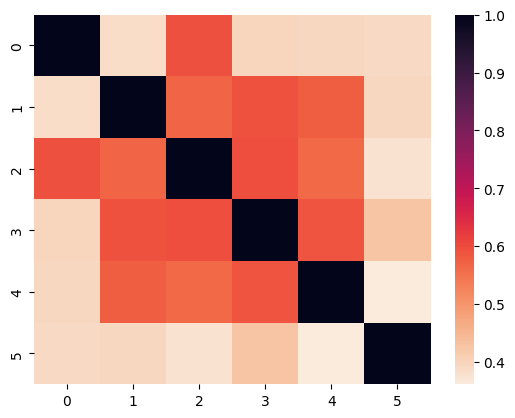

In [18]:
# We are going to be using our spark libraries which expect our data in a certain form, a vector, we will talk more about this later
assembler = VectorAssembler(inputCols = ['MntWines', 'MntFruits', 'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts', 'MntGoldProds'],
outputCol = 'features')

df = assembler.transform(customers_ifood).select("features")
# This correlation is a pyspark object
pearson_corr = Correlation.corr(df, "features", "pearson").collect()[0][0]
print("Pearson correlation matrix:\n", pearson_corr.toArray())
#Be careful when using python packages, is the input going to be big data?
import seaborn as sns
sns.heatmap(pearson_corr.toArray(), cmap = sns.cm.rocket_r)
plt.show()


%md
Footnote: what to do when multicollinearity issues are found?

Multicollinearity is a situation in which predictor variables in a regression model are highly correlated with each other. It can cause issues in the interpretation of coefficients and make it difficult to identify which predictor variables are truly contributing to the outcome variable.

There are several methods to address multicollinearity issues in the data:

1. Remove one or more of the correlated variables: One approach to deal with multicollinearity is to remove one or more of the correlated variables from the model. This can be done by either domain knowledge or using feature selection techniques.

2. Combine the correlated variables: Another approach is to combine the correlated variables into a single variable. This can be done by creating a new variable that is a weighted average of the correlated variables or by using principal component analysis (PCA).

3. Regularization techniques: Lasso or Ridge regularization techniques can be used to penalize the coefficients of the correlated variables, effectively reducing their impact on the model.

4. Increase the sample size: Increasing the sample size can help reduce the impact of multicollinearity by providing more data to estimate the coefficients accurately.

It is important to note that multicollinearity does not necessarily imply causality, and it is possible that the correlation is due to chance. Therefore, it is always important to interpret the results of correlation analysis in the context of the data and the research question at hand.

%md
### Feature engineering

Feature engineering is the process of transforming raw data into features that better represent the underlying problem to the predictive models, resulting in improved accuracy on unseen data.

In the case of the customers_ifood dataset, some examples of feature engineering are:

1. Transformation of data: Derive age from birth year. We can create a new feature "age" by subtracting the birth year from the current year (assuming current year is 2023). This could help the model to better understand the relationship between age and the response variable.

2. One-hot encoding: We can use one-hot encoding to transform categorical features such as "Education" and "Marital_Status" into numerical features. This allows the model to treat each category as a separate binary feature, instead of assuming that the categories have some kind of inherent ordering or numeric value.

3. Create interaction features: We can create new features that represent the interaction between two or more existing features. For example, we could create a feature that represents the product of the "MntWines" and "NumCatalogPurchases" features, which could help capture the relationship between these two variables.

4. Scaling/Normalization: We can apply scaling or normalization to the numerical features. This can help improve the performance of certain models (e.g. K-nearest neighbors, neural networks) by reducing the influence of features with large values.

5. Feature Selection: We can select a subset of the most important features for the model. This can improve model performance by reducing the risk of overfitting and making the model more interpretable. For example, we could use correlation analysis or feature importance scores to identify the most important features.

Overall, feature engineering is a critical step in the machine learning pipeline. By creating new features or transforming existing ones, we can provide our models with more relevant and meaningful information, leading to better predictions and insights.

Like most ML packages spark gives us tons to work with:

https://spark.apache.org/docs/latest/ml-features

In [8]:
# 1.1 Derive age from birth year, i.e. transfor year of birth into age
current_year = 2025
customers_ifood = customers_ifood.withColumn("Age", current_year - col("Year_Birth"))

In [9]:
# 1.2 Calculate the seniority of the customer from the data the customer signed up
customers_ifood = customers_ifood.withColumn("Dt_Customer", year(lit("2023")) - year("Dt_Customer"))

In [ ]:
# check
customers_ifood.select("Year_Birth", "Age", "Dt_Customer")

%md OneHotEncoder is a feature transformer in PySpark's MLlib library. It is used to convert a column of category indices to a column of binary vectors. This transformation is often used when dealing with categorical variables in machine learning algorithms.

In [10]:
# 2. One-hot encoding

# Check for unique values in categorical variables
cat_vars = ["Education", "Marital_Status"]
for col in cat_vars:
    customers_ifood.select(col).distinct().show()

+----------+
| Education|
+----------+
|  2n Cycle|
|       PhD|
|    Master|
|Graduation|
|     Basic|
+----------+

+--------------+
|Marital_Status|
+--------------+
|          YOLO|
|      Together|
|       Married|
|        Absurd|
|         Widow|
|      Divorced|
|         Alone|
|        Single|
+--------------+



In [11]:
# lets see how many non real values (YOLO, Absurd, Alone) exist
customers_ifood.groupBy("Marital_Status").agg(count("*").alias("count")).show()

+--------------+-----+
|Marital_Status|count|
+--------------+-----+
|          YOLO|    2|
|      Together|  569|
|       Married|  854|
|        Absurd|    2|
|         Widow|   76|
|      Divorced|  231|
|         Alone|    3|
|        Single|  470|
+--------------+-----+



In [12]:
# Lets drop these entries
from pyspark.sql.functions import col
# Create a list of values to drop
values_to_drop = ["YOLO", "Absurd", "Alone"]
# Filter the DataFrame to keep only rows where the Marital_Status column does not contain values_to_drop
customers_ifood = customers_ifood.filter(~col("Marital_Status").isin(values_to_drop))
# The filter method is used to drop rows from the DataFrame based on a condition. In this case, the ~col("Marital_Status").isin(values_to_drop) condition checks whether the Marital_Status column contains any of the values in the values_to_drop list, and returns True for rows where it does not. The ~ character negates the condition, so the filter method keeps only the rows where the condition is True. The resulting DataFrame will have the entries with 'YOLO', 'Absurd', and 'Alone' values in the Marital_Status column dropped.
customers_ifood.count()

2200

%md StringIndexer is a feature transformer in PySpark's MLlib library. It encodes a string column of labels to a column of label indices. The indices are ordered by label frequencies, so the most frequent label gets index 0, the next most frequent label gets index 1, and so on.

In [13]:
# Convert Education column to numerical form
indexer_edu = StringIndexer(inputCol = "Education", outputCol = "EducationIndex")
customers_ifood = indexer_edu.fit(customers_ifood).transform(customers_ifood)
# Convert Marital_Status column to numerical form
indexer_mar = StringIndexer(inputCol = "Marital_Status", outputCol = "MaritalIndex")
customers_ifood = indexer_mar.fit(customers_ifood).transform(customers_ifood)
# Apply one-hot encoding to the indexed columns
encoder = OneHotEncoder(inputCols = ["EducationIndex", "MaritalIndex"], outputCols = ["EducationVec", "MaritalVec"])

model = encoder.fit(customers_ifood)
customers_ifood = model.transform(customers_ifood)


#The code first uses StringIndexer to convert the categorical columns to numerical indices. Then, OneHotEncoderEstimator is used to perform one-hot encoding on the indexed columns, resulting in new columns named EducationVec and MaritalVec. The fit method is called on the encoder to create a model, and then the transform method is called to apply the encoding to the dataframe.

In [14]:
customers_ifood.show(3)

+----+----------+----------+--------------+------+-------+--------+-----------+-------+--------+---------+---------------+---------------+----------------+------------+-----------------+---------------+-------------------+-----------------+-----------------+------------+------------+------------+------------+------------+--------+-------------+---------+--------+---+--------------+------------+-------------+-------------+
|  ID|Year_Birth| Education|Marital_Status|Income|Kidhome|Teenhome|Dt_Customer|Recency|MntWines|MntFruits|MntMeatProducts|MntFishProducts|MntSweetProducts|MntGoldProds|NumDealsPurchases|NumWebPurchases|NumCatalogPurchases|NumStorePurchases|NumWebVisitsMonth|AcceptedCmp3|AcceptedCmp4|AcceptedCmp5|AcceptedCmp1|AcceptedCmp2|Complain|Z_CostContact|Z_Revenue|Response|Age|EducationIndex|MaritalIndex| EducationVec|   MaritalVec|
+----+----------+----------+--------------+------+-------+--------+-----------+-------+--------+---------+---------------+---------------+----------

In [ ]:
# Remove unnecessary columns (their values are constants)


In [ ]:
# Lets check again
customers_ifood.printSchema()

%md We have come across vectors again. Let's discuss in more detail:

A vector is a mathematical construct that is similar to lists and arrays, in that it is an ordered collection of numbers. A vector can be considered as a type of list where all elements are of the same numeric type, either integers or real numbers.

However, vectors have special mathematical properties that make them useful for machine learning. In particular, we can perform operations on vectors such as addition, scalar multiplication (multiplying all elements in the vector by a number), dot product (a special type of multiplication between two vectors), and others. These operations have specific interpretations and uses in machine learning.

In Spark ML, vectors can be either dense or sparse. A dense vector stores all of its elements explicitly, while a sparse vector only stores the non-zero elements and their indices, which can save a lot of memory if the vector has many zero elements.

https://www.databricks.com/blog/2014/07/16/new-features-in-mllib-in-spark-1-0.html

In [ ]:
from pyspark.ml.linalg import Vectors

# Create a dense vector
dense_vector = Vectors.dense([1.0, 2.0, 3.0, 0.0 , 2.0, 0.0, 0.0, 0.0, 0.0, 1.0])

# Create a sparse vector with the same data
sparse_vector = Vectors.sparse(10, [(0, 1.0), (1, 2.0), (2, 3.0), (4, 2.0), (9, 1.0)])  # only specify the non-zero elements

In [ ]:
# Feature Selection

# Personal related variables
cols_01 = ['Age', 'Income', 'Kidhome', 'Teenhome', 'EducationVec', 'MaritalVec','Response']

# Affiliation related
cols_02 = ['Dt_Customer', 'Recency','Response']

# Response to previous campains
cols_03 = ['AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5', 'AcceptedCmp1', 'AcceptedCmp2','Response']

# Amounts spend in product categories
cols_04 = ['MntWines', 'MntFruits', 'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts', 'MntGoldProds','Response']

# Channels - Purchases and visits
cols_05 = ['NumDealsPurchases', 'NumWebPurchases', 'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth','Response']

# custom
cols_06 = ['Income', 'Recency', 'NumWebVisitsMonth', 'MntWines', 'MntMeatProducts', 'MntGoldProds','EducationVec', 'MaritalVec','Response']

In [ ]:
# Select relevant features and label:

# selected_cols = list(set(cols_06).union(set(cols_05)))

# selected_cols: Contains the names of the columns that will be used as features and the label.


In [ ]:
# We will need to handle our different types of features differently


In [ ]:
# Assemble feature vector for categorical:


In [ ]:
# Assemble feature vector for numerical:


In [ ]:
# outputCol: Specifies the name of the output column that will contain the assembled feature vector.
# assembler.transform(data): Transforms the dataset by adding a new column containing the assembled feature vector.

# Normalize the numerical features

#We apply normalization to the vector column using Normalizer, specifying p=2.0 to perform L2 normalization. Finally, we transform the DataFrame with the Normalizer transformer, generating a new column called 'normalized_features'

In [ ]:
# Put all our feature together:


%md
## Training ML models

%md
#### Splitting data to train and test

When splitting data into training and test, some common rules of thumb are:
   
1. Use a 70/30 or 80/20 split for training and testing, respectively.
2. Randomly shuffle the data before splitting to avoid bias.
3. Ensure that the training and test sets have similar distributions of the target variable.

In [ ]:
# Split the data into train and test sets while ensuring similar distributions of the target variable

print('Train Set Distribution:')
# print percentage of responses 1 in train and test split 


%md
#### Logistic Regression Model

A logistic regression model is a statistical method used to analyze a binary outcome (e.g., success/failure or yes/no) based on one or more predictor variables. The model estimates the probability of the binary outcome by fitting a regression line to the data using a logistic function. The logistic function maps any input value to a probability between 0 and 1. The model calculates the likelihood of the observed outcomes given the predictor variables and estimates the coefficients of the regression line that maximize the likelihood. These coefficients are used to calculate the probability of the binary outcome for new observations.

In [ ]:
# Fit logistic regression model:


# LogisticRegression: Instantiates a logistic regression model with the specified parameters.
# featuresCol: Specifies the name of the input column containing the feature vector.
# labelCol: Specifies the name of the input column containing the label.
# lr.fit(training): Fits the logistic regression model to the training set.

%md https://spark.apache.org/docs/latest/api/python/reference/api/pyspark.ml.classification.LogisticRegressionModel.html

In [ ]:
# ROC

In [ ]:
# we evaluate the performance of the model using a BinaryClassificationEvaluator

# Evaluate model performance and get predictions. Make predictions on test set: 

 
# BinaryClassificationEvaluator: Instantiates a binary classification evaluator with the specified parameters.
# labelCol: Specifies the name of the input column containing the label.
# evaluator.evaluate(predictions): Evaluates the performance of the model on the test set using the area under the receiver operating characteristic (ROC) curve.
# print(f"Area under ROC curve: {auc}"): Prints the area under the ROC curve.

In [ ]:
# Print our ROC, this is using pandas, does that make sense?


%md ##### Note: how to read AUC

The Receiver Operating Characteristic (ROC) curve is a graphical representation of the performance of a binary classification model. It plots the True Positive Rate (TPR) against the False Positive Rate (FPR) at different classification thresholds.

The area under the ROC curve (AUC-ROC) is a measure of the overall performance of the model. It represents the probability that the model will rank a randomly chosen positive example higher than a randomly chosen negative example.

The AUC-ROC score ranges from 0 to 1, with a score of 0.5 indicating a model with random classification performance, and a score of 1 indicating a perfect model that can perfectly separate positive and negative examples.

Therefore, a higher AUC-ROC score indicates a better performing model, as it suggests that the model is better able to distinguish between positive and negative examples. A model with an AUC-ROC score of 0.7, for example, is generally considered to have acceptable discrimination ability, while a model with an AUC-ROC score of 0.9 or above is considered to have excellent discrimination ability.

In [ ]:
# By analyzing the feature importance of the trained model, we can determine which parameters are the best predictors of customer response:

#The output of this code is a list of the feature columns and their corresponding importances, in descending order. This will help us identify the most important parameters for predicting customer response.

# Print the feature importances
print('Feature Importances:')
for col, imp in zip(feature_cols, lr_model.coefficients):
    print('{}: {:.3f}'.format(col, imp))

# Plot the feature importance in a horizontal bar chart
fig, ax = plt.subplots(figsize=(8, 6))
ax.barh(feature_cols, lr_model.coefficients[:len(feature_cols)])
ax.set_title('Feature Importance Plot')
ax.set_xlabel('Importance')
plt.show()

%md
### Random Forest Classifier

A Random Forest Classifier is an ensemble learning method that builds multiple decision trees and combines their outputs to make a final prediction. Each tree is constructed using a random subset of the training data and a random subset of the features. The idea behind this approach is to reduce overfitting and improve the generalization of the model. The final prediction is based on the majority vote of the individual trees. Random Forest is a popular algorithm in machine learning due to its good performance, scalability, and ability to handle high-dimensional data.

In [ ]:
# Train Random Forest Classifier

# Make predictions on test set

# Evaluate model performance

# Get predicted probabilities and labels

# Calculate false positive rate and true positive rate

# Plot ROC curve
# plt.figure(figsize=(8, 6))
# plt.title('Receiver Operating Characteristic')
# plt.plot(fpr, tpr, color='darkorange', label=f'ROC curve (AUC = {roc_auc:.2f})')
# plt.plot([0, 1], [0, 1], color='navy', linestyle='--')
# plt.xlim([0.0, 1.0])
# plt.ylim([0.0, 1.05])
# plt.xlabel('False Positive Rate')
# plt.ylabel('True Positive Rate')
# plt.title('Receiver Operating Characteristic (ROC) Curve')
# plt.legend(loc="lower right")
# plt.show()

In [ ]:
# By analyzing the feature importance of the trained model, we can determine which parameters are the best predictors of customer response:

# Print the feature importances
# print('Feature Importances:')
# for col, imp in zip(feature_cols, rf_model.featureImportances.toArray()):
#     print('{}: {:.3f}'.format(col, imp))

#The output of this code is a list of the feature columns and their corresponding importances, in descending order. This will help us identify the most important parameters for predicting customer response.

# Plot the feature importance in a horizontal bar chart
# fig, ax = plt.subplots(figsize=(8, 6))
# ax.barh(feature_cols, rf_model.featureImportances.toArray()[:len(feature_cols)])
# ax.set_title('Feature Importance Plot')
# ax.set_xlabel('Importance')
# plt.show()

%md
#### Gradient-Boosted Trees Classifier

A Gradient-Boosted Trees Classifier is a machine learning algorithm that combines multiple decision trees to create a predictive model. Each tree is trained on the errors of the previous tree, resulting in an iterative process that improves the overall accuracy of the model. Gradient-Boosted Trees are often used for classification problems and have been shown to be effective in handling complex, non-linear relationships between variables.

In [ ]:
# Train Gradient-Boosted Trees Classifier

# Make predictions on test set
 = gbt_model.transform(test)

# Evaluate model performance


# Get predicted probabilities and labels

# probs = [float(i[0][1]) for i in results]
# labels = [i[1] for i in results]

# Calculate false positive rate and true positive rate


# Visualize ROC curve


# plt.figure(figsize=(8,6))
# plt.plot(fpr, tpr, color='darkorange', label=f'ROC curve (area = {roc_auc:.2f})')
# plt.plot([0, 1], [0, 1], color='navy', linestyle='--')
# plt.xlim([-0.02, 1.02])
# plt.ylim([-0.02, 1.02])
# plt.xlabel('False Positive Rate')
# plt.ylabel('True Positive Rate')
# plt.title('Receiver operating characteristic')
# plt.legend(loc="lower right")
# plt.show()

In [ ]:
# # By analyzing the feature importance of the trained model, we can determine which parameters are the best predictors of customer response:

# # Print the feature importances
# print('Feature Importances:')
# for col, imp in zip(feature_cols, gbt_model.featureImportances.toArray()):
#     print('{}: {:.3f}'.format(col, imp))

# #The output of this code is a list of the feature columns and their corresponding importances, in descending order. This will help us identify the most important parameters for predicting customer response.

# # Plot the feature importance in a horizontal bar chart
# fig, ax = plt.subplots(figsize=(8, 6))
# ax.barh(feature_cols, gbt_model.featureImportances.toArray()[:len(feature_cols)])
# ax.set_title('Feature Importance Plot')
# ax.set_xlabel('Importance')
# plt.show()